In [15]:
from qiskit import QuantumCircuit

def oracle(case, n):
    qc =QuantumCircuit(n+1)

    if case == "balanced":
        for qubit in range(n):
            qc.cx(qubit, n)

    return qc

In [19]:
def deutsch_jozsa(case, n):
    qc = QuantumCircuit(n+1, n)

    qc.x(n)
    qc.h(range(n+1))

    qc.barrier()

    oracle_circuit = oracle(case, n)
    qc.compose(oracle_circuit, inplace=True)

    qc.barrier()
    qc.h(range(n))

    qc.measure(range(n), range(n))
    return qc, case

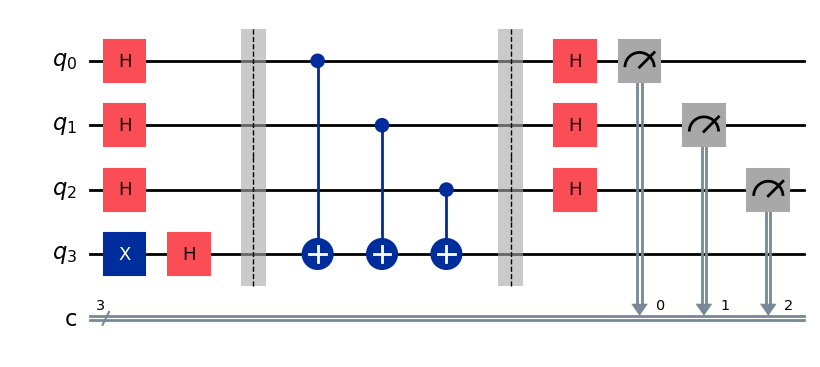

In [20]:
qc_bal, case_bal = deutsch_jozsa("balanced", 3)
qc_const, case_const = deutsch_jozsa("constant", 3)
qc_bal.draw(output='mpl')

In [21]:
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend('qasm_simulator')
result_bal = backend.run(transpile(qc_bal, backend)).result()
result_const = backend.run(transpile(qc_const, backend)).result()
print(f"Results {case_bal}: {result_bal.get_counts()}")
print(f"Results {case_const}: {result_const.get_counts()}")

Results balanced: {'111': 1024}
Results constant: {'000': 1024}
